In [14]:
import warnings
warnings.filterwarnings('ignore')

from IPython.core.display import display, HTML
display(HTML('<style>.container {width: 90% !important; }</style>'))

import glob, pyBigWig, shutil, os
import pandas as pd

import sys
sys.path.append('crestgv/')
from crestgv import crestgv

import seaborn as sns
import matplotlib.pyplot as plt

## Calculate "real" enrichment scores for BCELL genetics, super-PBMC

In [ ]:
genetic  = "genetics_test/Bcell_GO_0035456.tsv"
cgv      = crestgv(genetic=genetic, output="pvalues_test/Bcell_GO_0035456/", min_number_genetics=100, collection_name="super_pbmc")
df_cgv   = cgv.calculate_enrichment_score(lessNG=False, greater25k=False)

## Functions to calculate "null" enrichment scores and p-values

In [86]:
def run_null_cgv(genetic, output, random_collection="", random_collection_path=""):
    # Run CREST-GV to get the enrichment scores
    cgv_null = crestgv(genetic=genetic, output=output, 
                       min_number_genetics=100,
                       collection_name = random_collection, in_house_collection_path = random_collection_path) 
    df_cgv_null = cgv_null.calculate_enrichment_score(lessNG=False, greater25k=False) 
    return 

def run_bootstrap(output, N_BOOTS, SEED): 
    # Read the intermediate scores to generate the null distribution
    rounds_null = sorted(glob.glob(output + "/rounds/statistics_intermediate_round*")) 
    dfs_null = []
    for r in rounds_null:
        df = pd.read_csv(r, sep='\t', index_col=0)
        df = df[['CREST-GV']]
        dfs_null.append(df)
        
    df_null = pd.concat(dfs_null)

    # Sample with replacement 10,000 times from df_null to generate a full null
    df_null_bootstrap = df_null.sample(n=N_BOOTS, replace=True, random_state=SEED)

    # Display the two plots of raw null and bootstrap null side by side
    # Add titles to each sub-plot
    fig, (ax1, ax2) = plt.subplots(1,2)
    sns.histplot(df_null['CREST-GV'], kde=False, ax=ax1)
    ax1.set_title("raw_null")
    sns.histplot(df_null_bootstrap['CREST-GV'], kde=True, ax=ax2)
    ax2.set_title("bootstrapped_null")
    fig.show()

    return df_null_bootstrap

def generate_pvalue(genetic, output, real_df_cgv, random_collection="", random_collection_path="", N_BOOTS=10000, SEED=42):
    # Get the null enrichment scores
    run_null_cgv(genetic = genetic, output = output, 
                 random_collection=random_collection, random_collection_path=random_collection_path)
    # Get the null bootstrap distribution (this will plot a figure as it runs)
    df_null_bootstrap = run_bootstrap(output = output, N_BOOTS=N_BOOTS, SEED=SEED)

    # for each real enrichment score count the number of times a value equal to or greater than the observed value was sampled in the bootstrap null and divide by the number of samples
    df_cgv_with_pvals = real_df_cgv
    df_cgv_with_pvals['empirical_pvalue'] = real_df_cgv['CREST-GV_all'].apply(lambda x: (df_null_bootstrap['CREST-GV'] >= x).sum()/N_BOOTS)

    return df_cgv_with_pvals

def plot_pvalue(df_cgv_with_pvals):
    # Arrange by the enrichment score
    df_cgv_with_pvals = df_cgv_with_pvals.sort_values('CREST-GV_all',
                                                     ascending = False)
    
    # Plot the enrichment score and p-value side-by-side
    fig, (ax1, ax2) = plt.subplots(1,2)
    sns.heatmap(df_cgv_with_pvals[['CREST-GV_all']], annot=True, ax=ax1, 
                fmt='.2f', cmap='rocket_r', vmin=0)
    ax1.set_title("enrichment_score")
    sns.heatmap(df_cgv_with_pvals[['empirical_pvalue']], annot=True, ax=ax2, 
                fmt='.2f', cmap='Blues_r', vmin=0, vmax=1)
    ax2.set_title("empirical_pvalue")
    ax2.set_yticklabels([])
    fig.show()
    
    return

## First try this on a small but related collection with few celltypes - immune-cell

Removing NaN rows from loaded file ...
Total number of used variants in CREST-GV: 527
Calculating (1) total number of base-pairs within peaks and (2) total number of base-pairs within peaks divided by uniquely mappable base-pairs ...


100%|██████████| 15/15 [00:01<00:00, 12.75it/s]


Intersecting genetic with peak regions ...


100%|██████████| 15/15 [00:03<00:00,  4.39it/s]

For each fold, parallelised shuffling background ...


...

Calculating statistics ...
Adding shuffled background ...


100%|██████████| 5/5 [00:14<00:00,  2.93s/it]


Calculating statistics ...
Adding shuffled background ...


100%|██████████| 5/5 [00:15<00:00,  3.01s/it]


Calculating statistics ...
Cleaning temporary files ...
Processing genetics finished.


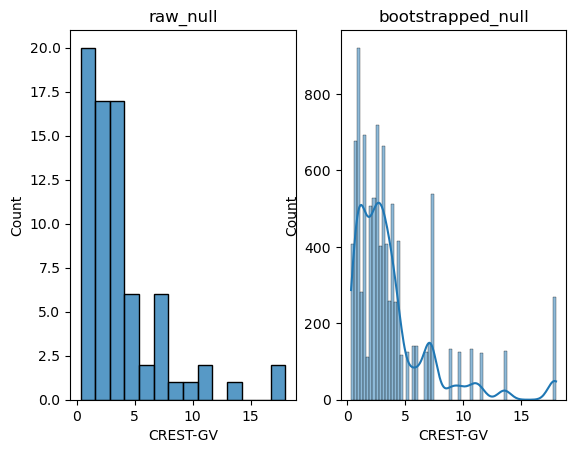

In [87]:
random_collection = "immune_cell"
output = "pvalues_test/Bcell_GO_0035456_" + random_collection + "/"

df_cgv_with_pvals = generate_pvalue(genetic = genetic, output = output, real_df_cgv = df_cgv,
                                    random_collection = random_collection, random_collection_path="")

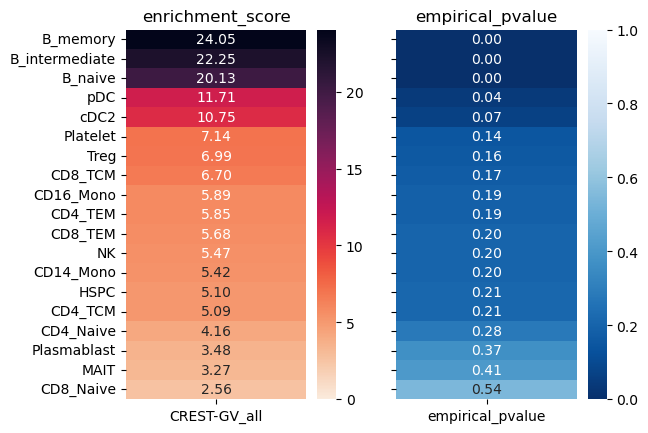

In [88]:
plot_pvalue(df_cgv_pvals)

## Now try on a much larger but unrelated collection to see how the p-values change - catlas-adult

Removing NaN rows from loaded file ...
Total number of used variants in CREST-GV: 527
Calculating (1) total number of base-pairs within peaks and (2) total number of base-pairs within peaks divided by uniquely mappable base-pairs ...


100%|██████████| 111/111 [00:07<00:00, 15.09it/s]


Intersecting genetic with peak regions ...


100%|██████████| 111/111 [00:35<00:00,  3.16it/s]


For each fold, parallelised shuffling background ...
Calculating (1) total number of base-pairs within peaks and (2) total number of base-pairs within peaks divided by uniquely mappable base-pairs ...


...

Calculating statistics ...
Adding shuffled background ...


100%|██████████| 5/5 [02:04<00:00, 24.84s/it]


Calculating statistics ...
Adding shuffled background ...


100%|██████████| 5/5 [01:59<00:00, 23.84s/it]


Calculating statistics ...
Cleaning temporary files ...
Processing genetics finished.


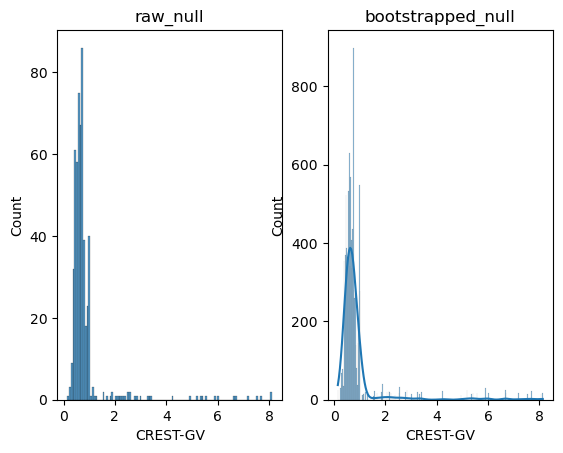

In [80]:
random_collection = "catlas_adult"
output = "pvalues_test/Bcell_GO_0035456_" + random_collection + "/"

df_cgv_with_pvals = generate_pvalue(genetic = genetic, output = output, real_df_cgv = df_cgv,
                                    random_collection = random_collection, random_collection_path="")

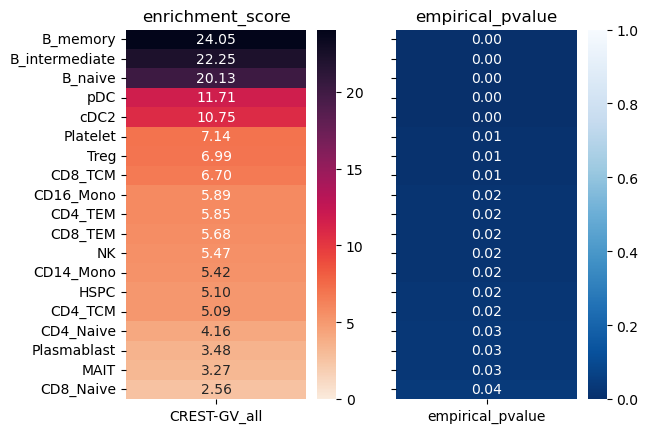

In [81]:
plot_pvalue(df_cgv_pvals)

In [96]:
## Now try on a set of 25 cell types chosen at random from the whole list
our_df = pd.read_csv('/project/Wellcome_Discovery/svenkat/CREST-GV/data/our_data_collection.txt', sep='\t')
our_df = our_df.dropna()

In [97]:
# Sample rows at random without replacement from this dataframe
our_df_25 = our_df.sample(25, replace=False, random_state=42)
our_df_50 = our_df.sample(50, replace=False, random_state=42)

In [92]:
%%bash
mkdir /project/Wellcome_Discovery/svenkat/CREST-GV/data/random_25
ls /project/Wellcome_Discovery/datashare/CREST-GV_collection/calderon/peaks

1001-Bulk_B-S_L-tron.bed
1001-Bulk_B-U_L-tron.bed
1001-CD8pos_T-S_L-tron.bed
1001-CD8pos_T-U_L-tron.bed
1001-Central_memory_CD8pos_T-S_L-tron.bed
1001-Central_memory_CD8pos_T-U_L-tron.bed
1001-Effector_CD4pos_T-S_L-tron.bed
1001-Effector_CD4pos_T-U_L-tron.bed
1001-Effector_memory_CD8pos_T-S_L-tron.bed
1001-Effector_memory_CD8pos_T-U_L-tron.bed
1001-Follicular_T_Helper-S_L-tron.bed
1001-Follicular_T_Helper-U_L-tron.bed
1001-Gamma_delta_T-U_L-tron.bed
1001-Immature_NK-U_L-tron.bed
1001-Mature_NK-S_L-tron.bed
1001-Mature_NK-U_L-tron.bed
1001-Mem_B-S_L-tron.bed
1001-Mem_B-U_L-tron.bed
1001-Memory_NK-U_L-tron.bed
1001-Memory_Teffs-S_L-tron.bed
1001-Memory_Teffs-U_L-tron.bed
1001-Memory_Tregs-S_L-tron.bed
1001-Memory_Tregs-U_L-tron.bed
1001-Monocytes-S_L-tron.bed
1001-Monocytes-U_L-tron.bed
1001-Myeloid_DCs-U_L-tron.bed
1001-Naive_B-S_L-tron.bed
1001-Naive_B-U_L-tron.bed
1001-Naive_CD8_T-S_L-tron.bed
1001-Naive_CD8_T-U_L-tron.bed
1001-Naive_Teffs-S_L-tron.bed
1001-Naive_Teffs-U_L-tron.bed
10

In [98]:
our_df_25.head()

,collection_folder_name,celltype
268,catlas_adult,Pericyte_Muscularis
73,calderon,1002-Memory_Tregs-S
289,catlas_adult,Transitional_Cortical
155,calderon,1004-Naive_CD8_T-S
104,calderon,1003-Follicular_T_Helper-U
